In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("1_1.csv")
df.head()

,sec,nanosec,frame_id,name,position.x,position.y,position.z
0,1773047263,525826153,world,cf231,-2.622457,-1.824670,0.668747
1,1773047263,525826153,world,cf231_leg,-2.626433,-1.832977,0.654670
2,1773047263,531139826,world,cf231,-2.623413,-1.823138,0.672598
3,1773047263,531139826,world,cf231_leg,-2.626763,-1.832156,0.658283
4,1773047263,535956869,world,cf231,-2.624442,-1.821668,0.676731


In [3]:
df_cf231 = df[df["name"] == "cf231"]
df_cf231.head()

,sec,nanosec,frame_id,name,position.x,position.y,position.z
0,1773047263,525826153,world,cf231,-2.622457,-1.824670,0.668747
2,1773047263,531139826,world,cf231,-2.623413,-1.823138,0.672598
4,1773047263,535956869,world,cf231,-2.624442,-1.821668,0.676731
6,1773047263,541061638,world,cf231,-2.625515,-1.820291,0.680664
8,1773047263,546037368,world,cf231,-2.626521,-1.818697,0.684227


In [4]:
df_leg = df[df["name"] == "cf231_leg"]
df_leg.head()

,sec,nanosec,frame_id,name,position.x,position.y,position.z
1,1773047263,525826153,world,cf231_leg,-2.626433,-1.832977,0.654670
3,1773047263,531139826,world,cf231_leg,-2.626763,-1.832156,0.658283
5,1773047263,535956869,world,cf231_leg,-2.627262,-1.831406,0.662001
7,1773047263,541061638,world,cf231_leg,-2.627484,-1.830439,0.665612
9,1773047263,546037368,world,cf231_leg,-2.627995,-1.829688,0.669402


In [5]:
df_cf231["time"] = df_cf231["sec"] + (1e-9 * df_cf231["nanosec"])
df_cf231["time"] = df_cf231["time"] - df_cf231["time"].iloc[0]

df_leg["time"] = df_leg["sec"] + (1e-9 * df_leg["nanosec"])
df_leg["time"] = df_leg["time"] - df_leg["time"].iloc[0]

In [6]:
df_cf231 = df_cf231.rename(columns = {"position.x" : "cf231.x", "position.y" : "cf231.y" , 
                                      "position.z" : "cf231.z"})
df_cf231 = df_cf231.drop(["sec", "nanosec", "frame_id", "name"], axis = 1)
df_leg = df_leg.rename(columns = {"position.x" : "leg.x" , "position.y" : "leg.y", 
                                  "position.z" : "leg.z" })
df_leg = df_leg.drop(["sec", "nanosec" , "frame_id", "name"], axis = 1)

In [7]:
df_cf231.head()

,cf231.x,cf231.y,cf231.z,time
0,-2.622457,-1.824670,0.668747,0.000000
2,-2.623413,-1.823138,0.672598,0.005314
4,-2.624442,-1.821668,0.676731,0.010131
6,-2.625515,-1.820291,0.680664,0.015235
8,-2.626521,-1.818697,0.684227,0.020211


In [8]:
df1 = pd.merge(df_cf231, df_leg, on = "time", how = "inner")
df1.head()

,cf231.x,cf231.y,cf231.z,time,leg.x,leg.y,leg.z
0,-2.622457,-1.824670,0.668747,0.000000,-2.626433,-1.832977,0.654670
1,-2.623413,-1.823138,0.672598,0.005314,-2.626763,-1.832156,0.658283
2,-2.624442,-1.821668,0.676731,0.010131,-2.627262,-1.831406,0.662001
3,-2.625515,-1.820291,0.680664,0.015235,-2.627484,-1.830439,0.665612
4,-2.626521,-1.818697,0.684227,0.020211,-2.627995,-1.829688,0.669402


In [9]:
## negative values in the z values of the leg is meaning less 
idx_first = df1[df1["leg.z"] < 0].index[0]
df1 = df1.loc[:idx_first-1]
df1.head()

,cf231.x,cf231.y,cf231.z,time,leg.x,leg.y,leg.z
0,-2.622457,-1.824670,0.668747,0.000000,-2.626433,-1.832977,0.654670
1,-2.623413,-1.823138,0.672598,0.005314,-2.626763,-1.832156,0.658283
2,-2.624442,-1.821668,0.676731,0.010131,-2.627262,-1.831406,0.662001
3,-2.625515,-1.820291,0.680664,0.015235,-2.627484,-1.830439,0.665612
4,-2.626521,-1.818697,0.684227,0.020211,-2.627995,-1.829688,0.669402


In [10]:
## finding the minimum body z position
idx_cf231 = df1["cf231.z"].idxmin()
idx_leg = df1["leg.z"].idxmin()
print(f"{idx_cf231} - body and {idx_leg} - leg") 
## initial distance body and leg
# Take first 100 samples (or you can choose any slice)
df_sample = df1.iloc[:100]

# Compute difference and its mean
initial_length = (df_sample["cf231.z"] - df_sample["leg.z"]).mean()

print(initial_length)

3226 - body and 3226 - leg
0.016833755373954776


In [11]:
df1.to_csv("final1.csv")

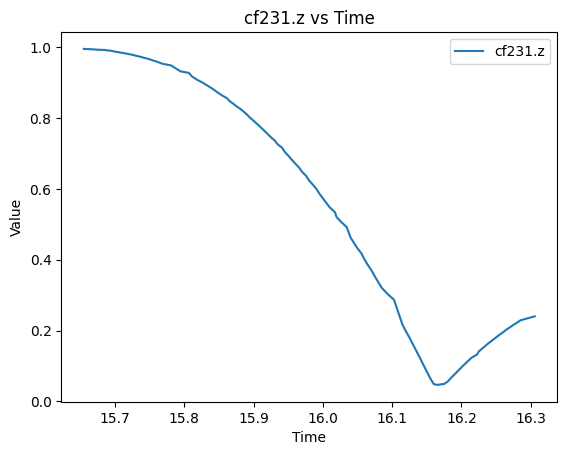

In [12]:
# Slice required range this is the free fall range
df_slice = df1.loc[3130:3251]

# Plot both
plt.plot(df_slice["time"], df_slice["cf231.z"], label="cf231.z")

plt.xlabel("Time")
plt.ylabel("Value")
plt.title("cf231.z vs Time")
plt.legend()
plt.show()

In [13]:
t = df_slice["time"]
t = t.to_numpy().reshape((len(t), 1))

In [14]:
import scipy
def computeSpline(str, arr, t, steps, cols):
  if len(t.shape) == 1:
    t = t.reshape((t.shape[0], 1))
  splines = {}
  for i in range(len(cols)):
    splines[str + "_" + cols[i]] = scipy.interpolate.CubicSpline(t[:, 0], arr[:, i])(steps, 0)
  return splines

In [15]:
sampling_bounds = [np.min(t), np.max(t)]
sampling_steps = np.arange(sampling_bounds[0], sampling_bounds[1], 0.005)[:-1]
sampled_data = {"t" : sampling_steps}

# adding the z position of the body
cf231_z = df_slice["cf231.z"].to_numpy()
cf231_z = cf231_z.reshape((cf231_z.shape[0], 1))
sampled_data.update(computeSpline("cf231", cf231_z, t, sampling_steps, "z")) 

#adding the z position of the leg
leg_z = df_slice["leg.z"].to_numpy()
leg_z = leg_z.reshape((leg_z.shape[0], 1))
sampled_data.update(computeSpline("leg", leg_z, t, sampling_steps, "z"))

In [16]:
print(f"{sampled_data.keys()}")

dict_keys(['t', 'cf231_z', 'leg_z'])


In [17]:
df_sampled = pd.DataFrame(sampled_data)
df_sampled["compression"] = df_sampled["cf231_z"] - df_sampled["leg_z"] 
df_sampled["compression"] = initial_length - df_sampled["compression"]
df_sampled.head()

,t,cf231_z,leg_z,compression
0,15.655214,0.995826,0.981019,0.002027
1,15.660214,0.995324,0.980963,0.002472
2,15.665214,0.995037,0.980260,0.002057
3,15.670214,0.994402,0.979606,0.002038
4,15.675214,0.993543,0.978783,0.002074


Minimum compression: -0.013084396370841349
Time at minimum: 16.165213832855304
Time period: 0.03000000000000469


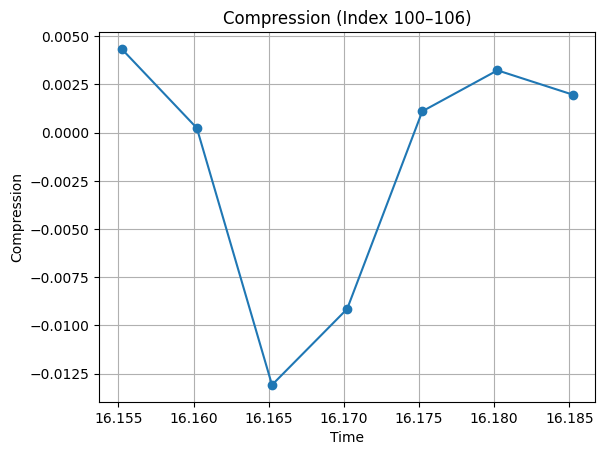

In [18]:
# Slice index range
df_slice = df_sampled.loc[100:106]

# Plot
plt.plot(df_slice["t"], df_slice["compression"], marker='o')

plt.xlabel("Time")
plt.ylabel("Compression")
plt.title("Compression (Index 100–106)")

plt.grid(True)

# Find minimum value and corresponding time
min_idx = df_slice["compression"].idxmin()
min_val = df_slice.loc[min_idx, "compression"]
min_time = df_slice.loc[min_idx, "t"]

# Time period (duration of slice)
time_period = df_slice["t"].iloc[-1] - df_slice["t"].iloc[0]

print(f"Minimum compression: {min_val}")
print(f"Time at minimum: {min_time}")
print(f"Time period: {time_period}")

plt.show()